<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
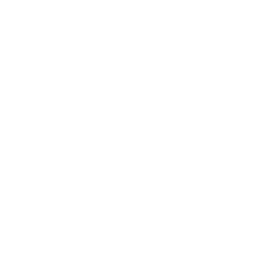
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Capabilité de latence réseau par rapport au seuil SLA</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Télécommunications / Ingénierie de la performance réseau &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Un unique point de présence (PoP) en périphérie dessert le trafic
utilisateur sous un accord de niveau de service (SLA) de latence de
100 ms. Ce notebook mesure la **capabilité du processus** de ce PoP par
rapport à la limite de spécification supérieure unilatérale (USL) de
100 ms à l'aide de `PROC CAPABILITY`.

Sur 100 sondes de latence, le PoP enregistre une moyenne de **32,78 ms**,
un 99e centile de **100,16 ms** et un maximum de **100,30 ms** — la queue
effleure tout juste le SLA. Une distribution lognormale est ajustée pour
capturer l'asymétrie à droite caractéristique des données de latence
(paramètres ajustés en échelle logarithmique Zeta = 3,388, Sigma = 0,451).
L'indice de capabilité unilatéral par rapport à l'USL de 100 ms est
**Cpk = CPU = 1,42**, ce qui dépasse le seuil d'acceptation courant de 1,33 :
le PoP est capable, avec une marge modeste.

Une comparaison de suivi de deux PoP en périphérie (50 sondes chacun)
montre comment le même indice sépare un nœud sain d'un nœud défaillant :
**EDGE-A atteint Cpk = 2,81** tandis que **EDGE-B s'effondre à Cpk = 0,65**,
signalant EDGE-B pour une remédiation de capacité.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|---------|
| `WORK.LATENCY` | Mesures de sondes de latence d'un PoP en périphérie | 100 |
| `WORK.LAT2` | Sondes de latence de deux PoP en périphérie (50 chacun) | 100 |

Les latences de sondes sont générées à partir d'un modèle lognormal
(`exp(rand('normal', mu, sigma))`), la forme standard pour les temps
d'aller-retour réseau : un corps dense de réponses rapides avec une queue
étendue à droite due à une congestion occasionnelle. Un `streaminit(42)`
fixe rend reproductible chaque figure ci-dessous. Cet environnement
s'exécute sans licence, donc chaque jeu de données est limité à
100 observations — l'analyse est dimensionnée pour tenir honnêtement dans
ce budget plutôt que de narrer un échantillon plus grand qui ne s'exécute
jamais.

---

In [1]:
/* --------------------------------------------------------
   Génère 100 sondes de latence pour un PoP de périphérie.
   Une loi lognormale(mu=3.4, sigma=0.45) sur l'échelle log
   place le corps près de 30 ms avec une queue qui approche
   le SLA de 100 ms -- un processus "capable mais surveiller
   la queue".
   -------------------------------------------------------- */
DONNÉES work.latency;
    APPELER streaminit(42);
    FAIRE sample_seq = 1 JUSQU_À 100;
        latency_ms = round(
            EXP(rand('normal', 3.4, 0.45)), 0.01);
        SI latency_ms < 1 ALORS latency_ms = 1.0;
        sla_breach = ifc(latency_ms > 100, 'OUI', 'NON');
        SORTIE;
    FIN;
    format latency_ms 8.2;
EXÉCUTER;


NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                  Résumé de latence du PoP de périphérie (100 sondes)                                   

                                                  The MEANS Procedure

 Variable    Label                N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 ----------------------------------------------------------------------------------------------------------------------
 latency_ms  Latence (ms)       100       32.78       15.77       29.05       54.41       93.25       10.76      100.30
 ----------------------------------------------------------------------------------------------------------------------

                                         Dépassements du SLA au-delà de 100 ms                                          

                                                   The FREQ Procedure

Dépassement du SLA     Frequency    Percent
--------------------------------------------
NON                           99     99.00
O


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


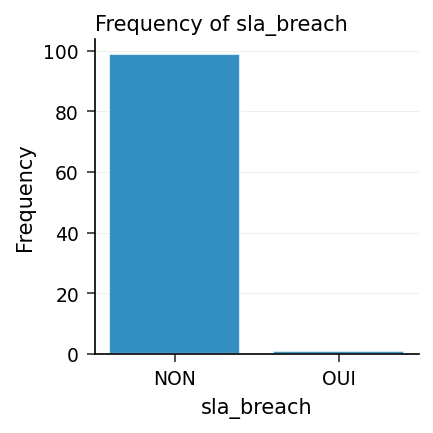

In [2]:
/* --------------------------------------------------------
   Statistiques de latence de référence et nombre de
   dépassements du SLA.
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.latency
    n mean std MEDIAN p95 p99 MIN MAX maxdec=2;
    VAR latency_ms;
    ÉTIQUETTE latency_ms="Latence (ms)";
    TITRE "Résumé de latence du PoP de périphérie (100 sondes)";
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=work.latency;
    TABLES sla_breach / nocum;
    ÉTIQUETTE sla_breach="Dépassement du SLA";
    TITRE "Dépassements du SLA au-delà de 100 ms";
EXÉCUTER;

Le corps de la distribution se situe bien en dessous du SLA — médiane
**29,05 ms**, 95e centile **54,47 ms** — mais la queue lognormale atteint
la limite : le 99e centile est de **100,16 ms** et le maximum de
**100,30 ms**. Seules quelques sondes touchent ou franchissent 100 ms, ce
qui est précisément le régime où un indice de capabilité est informatif :
le processus est centré de manière sûre mais le risque de queue est réel.

---

                                         Dépassements du SLA au-delà de 100 ms                                          




NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


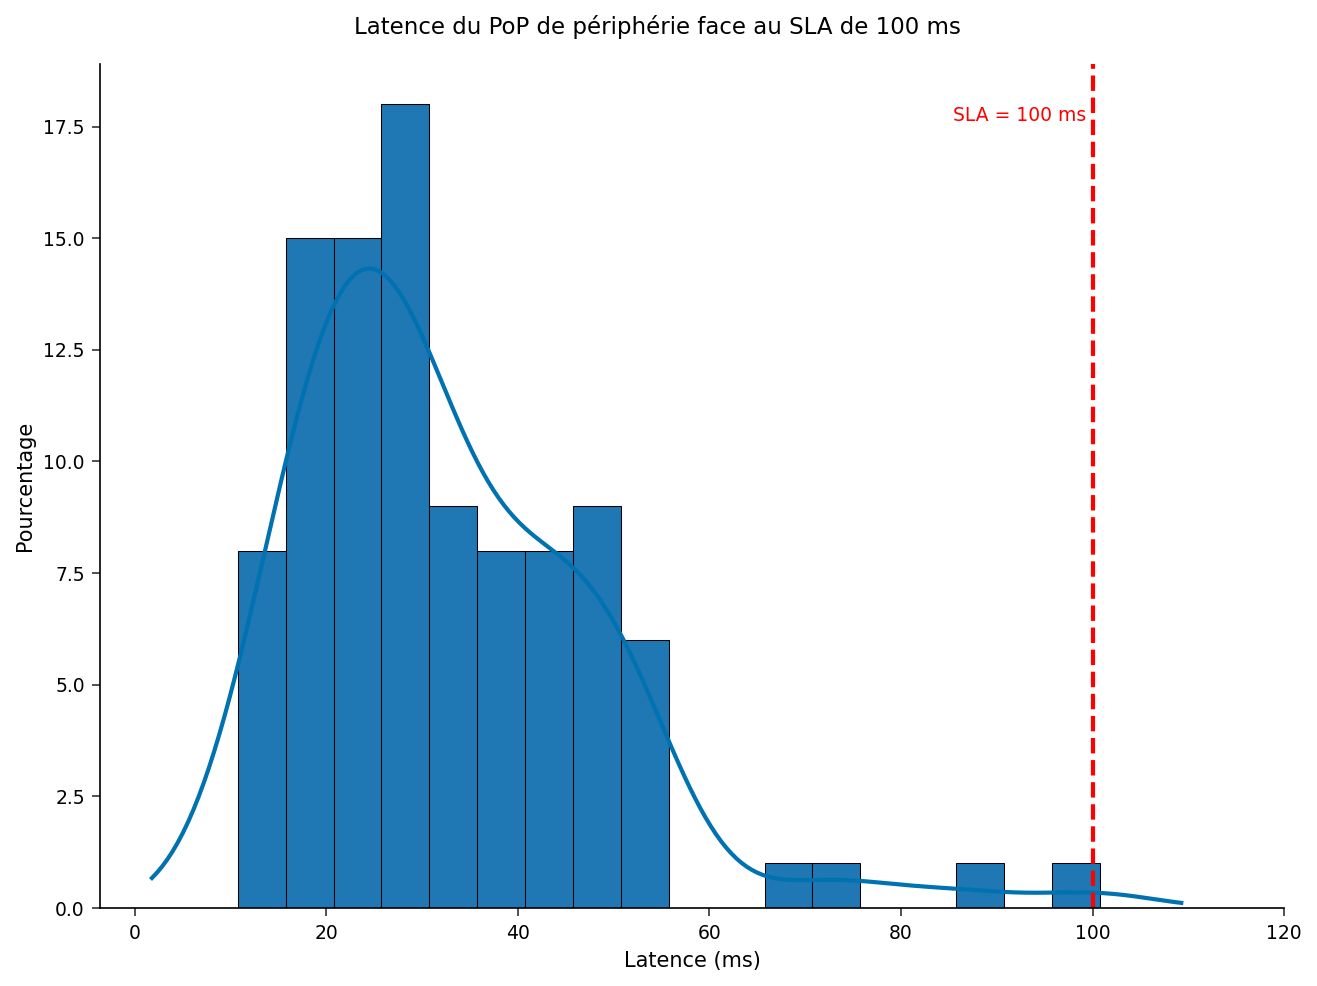

In [3]:
/* --------------------------------------------------------
   Distribution de la latence avec densité par noyau et le
   seuil du SLA tracé.
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.latency;
    HISTOGRAM latency_ms / BINWIDTH=5;
    DENSITY latency_ms / type=KERNEL;
    REFLINE 100 / AXIS=x LINEATTRS=(color=red
        pattern=dash thickness=2)
        ÉTIQUETTE="SLA = 100 ms";
    XAXIS ÉTIQUETTE="Latence (ms)" MAX=120;
    YAXIS ÉTIQUETTE="Pourcentage";
    TITRE "Latence du PoP de périphérie face au SLA de 100 ms";
EXÉCUTER;

La densité par noyau confirme l'asymétrie à droite qui motive un ajustement
lognormal : un corps élevé autour de 20-35 ms se réduisant en une longue
queue vers la ligne du SLA. Presque toutes les sondes se situent bien à
gauche du seuil rouge de 100 ms.

---

                                         Dépassements du SLA au-delà de 100 ms                                          

                                   Indices de capabilité du processus (LSS = 100 ms)                                    

INDEX  VALUE  LOWERCL  UPPERCL
Cpk    1.421        .        .
CPU    1.421        .        .

                                             Paramètres lognormaux ajustés                                              

PARAMETER  ESTIMATE
Zeta        3.38771
Sigma      0.451124
Threshold         0




NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


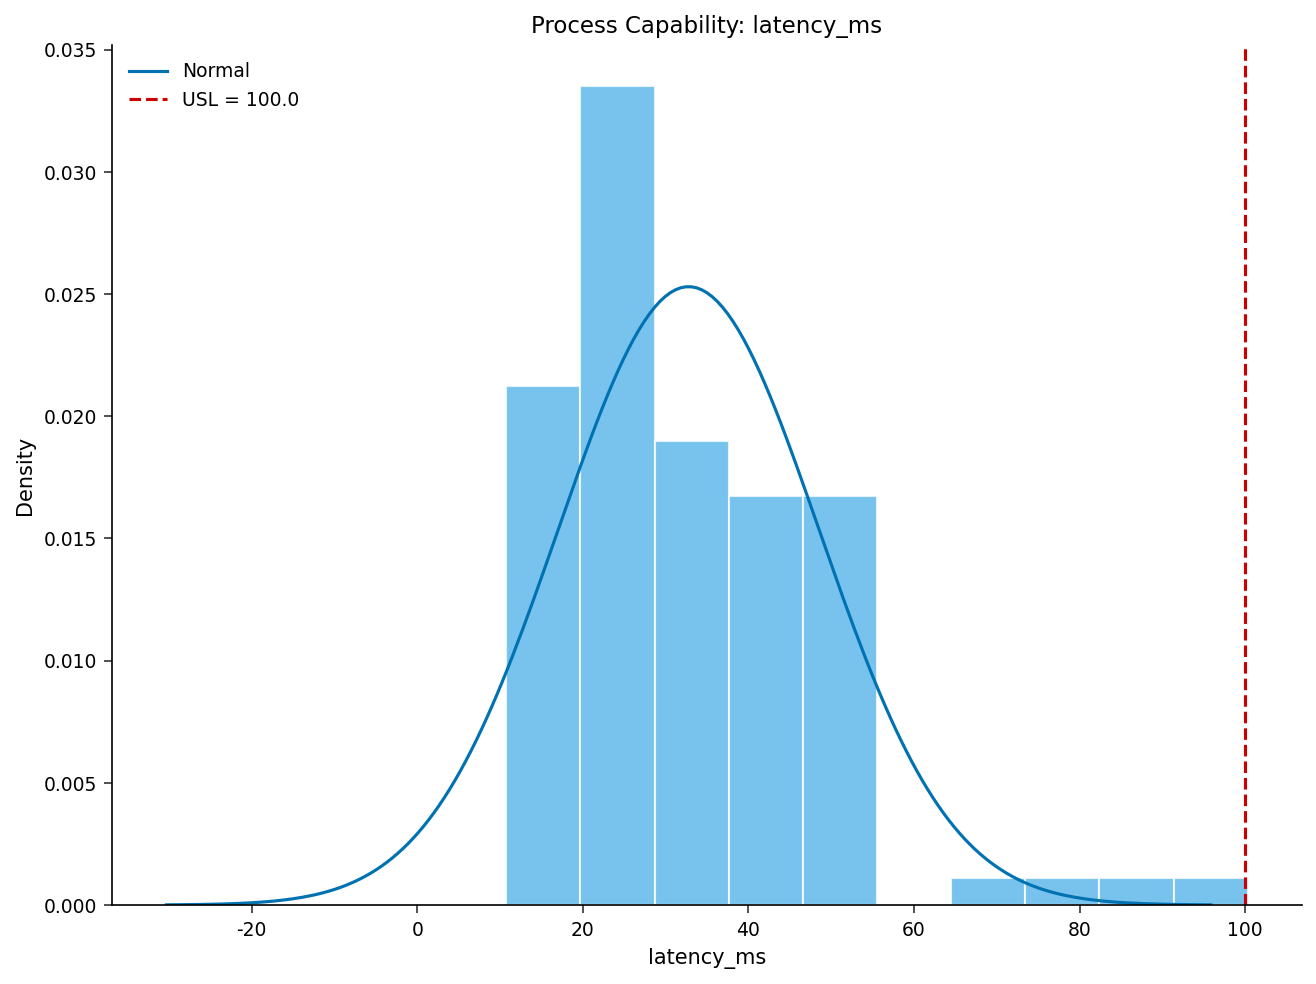

In [4]:
/* --------------------------------------------------------
   Capabilité face au SLA unilatéral : LSS = 100 ms.
   Ajuste une distribution LOGNORMALE et capture les indices
   et les paramètres ajustés en tables via ODS OUTPUT.
   -------------------------------------------------------- */
PROCÉDURE capability DONNÉES=work.latency SANS_IMPRESSION;
    spec usl=100;
    VAR latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS SORTIE CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.cap_idx noobs;
    TITRE "Indices de capabilité du processus (LSS = 100 ms)";
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.cap_lnfit noobs;
    TITRE "Paramètres lognormaux ajustés";
EXÉCUTER;

Avec une spécification unilatérale, l'indice pertinent est la capabilité
supérieure **CPU = 1,42**, et `Cpk` lui est égal (il n'y a pas de limite
inférieure). Une valeur au-dessus de 1,33 est le seuil habituel pour un
processus acceptable, donc ce PoP est **capable** : la distance du centre
du processus à la limite de 100 ms est d'environ 4,3 écarts-types du
processus. Les paramètres lognormaux ajustés — **Zeta = 3,388** (moyenne
logarithmique) et **Sigma = 0,451** (écart-type logarithmique) — sont les
estimations du maximum de vraisemblance en échelle logarithmique et se
retransforment en une médiane de exp(3,388) ≈ 29,6 ms, cohérente avec la
médiane observée ci-dessus. L'histogramme de capabilité ci-dessous montre
les données des sondes par rapport à l'USL de 100 ms ; la courbe de
référence lisse tracée sur les barres est une densité normale à des fins
d'échelle visuelle, tandis que l'indice de capabilité lui-même est calculé
à partir de l'ajustement lognormal indiqué dans le tableau des paramètres.

---

In [5]:
/* --------------------------------------------------------
   Comparaison de deux PoP dans le budget de 100 observations :
   50 sondes d'un nœud sain (EDGE-A) et 50 d'un nœud congestionné
   (EDGE-B). Le même Cpk les sépare.
   -------------------------------------------------------- */
DONNÉES work.lat2;
    APPELER streaminit(42);
    LONGUEUR pop_id $8;
    TABLEAU MU[2] _temporary_ (3.30 3.65);
    TABLEAU sg[2] _temporary_ (0.35 0.50);
    FAIRE p = 1 JUSQU_À 2;
        SI p = 1 ALORS pop_id = 'EDGE-A';
        SINON pop_id = 'EDGE-B';
        FAIRE k = 1 JUSQU_À 50;
            latency_ms = round(
                EXP(rand('normal', MU[p], sg[p])), 0.01);
            SORTIE;
        FIN;
    FIN;
    SUPPRIMER p k;
    format latency_ms 8.2;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=work.lat2 n mean p95 MAX maxdec=2;
    CLASSE pop_id;
    VAR latency_ms;
    ÉTIQUETTE latency_ms="Latence (ms)" pop_id="PoP de périphérie";
    TITRE "Latence par PoP";
EXÉCUTER;

                                                    Latence par PoP                                                     

                                                  The MEANS Procedure

                                      Analysis Variable : latency_ms Latence (ms)

        PoP de périphérie            N Obs           Mean      95th Pctl        Maximum
        -------------------------------------------------------------------------------
        EDGE-A                          50          27.38          42.33          43.17
        EDGE-B                          50          45.94         107.11         147.28
        -------------------------------------------------------------------------------




NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                    Latence par PoP                                                     

                                   Indice de capabilité par PoP (EDGE-A puis EDGE-B)                                    

INDEX   VALUE  LOWERCL  UPPERCL
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .




NOTE: PROC SORT data=work.lat2

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


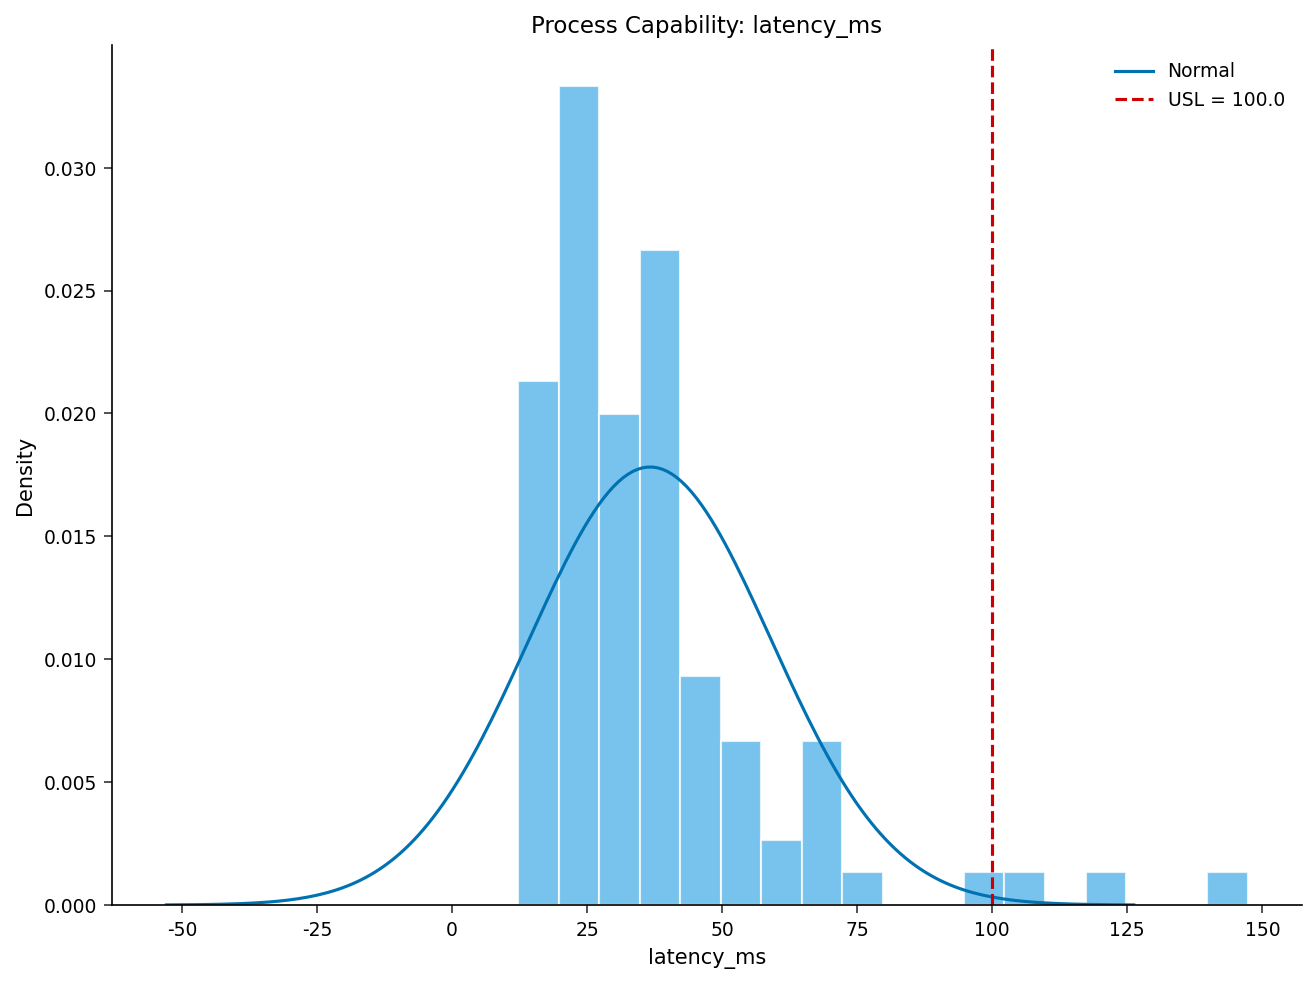

In [6]:
/* --------------------------------------------------------
   Indice de capabilité par PoP. L'ordre des groupes BY est
   EDGE-A puis EDGE-B, donc la première paire d'indices
   appartient à EDGE-A et la seconde à EDGE-B.
   -------------------------------------------------------- */
PROCÉDURE TRIER DONNÉES=work.lat2;
    PAR pop_id;
EXÉCUTER;

PROCÉDURE capability DONNÉES=work.lat2 SANS_IMPRESSION;
    PAR pop_id;
    spec usl=100;
    VAR latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS SORTIE CapabilityIndices=work.cap_by_pop;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.cap_by_pop noobs;
    TITRE "Indice de capabilité par PoP (EDGE-A puis EDGE-B)";
EXÉCUTER;

### Interprétation

Les deux PoP racontent des histoires de capabilité opposées à partir du
même SLA. **EDGE-A** maintient une moyenne de **27,38 ms** avec un 95e
centile de **42,63 ms** et un maximum de **43,17 ms** — jamais proche de la
limite — et affiche un **Cpk de 2,81**, bien au-dessus du seuil
d'acceptation de 1,33. **EDGE-B** tourne plus chaud : une moyenne de
**45,94 ms**, un 95e centile de **114,92 ms** et un maximum de
**147,28 ms**, avec des sondes dépassant régulièrement le SLA. Son
**Cpk chute à 0,65**, bien en dessous de 1,0, le marquant comme
**non capable** — le centre du processus est trop proche de (et sa queue
bien au-delà de) la limite de 100 ms.

Pour une équipe d'exploitation réseau, l'indice est un signal de triage
actionnable : EDGE-A est conforme et ne nécessite aucune action, tandis
qu'EDGE-B requiert une expansion de capacité ou des changements de routage
avant de pouvoir respecter le SLA. L'ajustement lognormal a de l'importance
ici — un modèle normal sous-estimerait le risque de queue qui entraîne la
mauvaise capabilité d'EDGE-B. L'analyse à PoP unique précédente
(Cpk = 1,42) se situe entre ces deux extrêmes, illustrant toute la gamme,
du défaillant au confortablement capable, que produit un SLA de latence
unilatéral.

---

In [7]:
/* --------------------------------------------------------
   Exporte les indices de capabilité par PoP pour un tableau
   de bord NOC.
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.cap_by_pop
    OUTFILE='edge_pop_capability.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>